# CNN Baseline for Skeleton Action Recognition

Main changes relative to the earlier baseline:
- raw skeleton stream + motion stream
- skeleton transformer module
- multi-person maxout merge


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Cell 1: Imports
import os
import math
import pickle
import random
import numpy as np

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt


In [3]:
# Cell 2: Seed and device
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
print("torch version:", torch.__version__)


device: cuda
torch version: 2.10.0+cu128


In [4]:
# Cell 3: Path to your pkl file
PKL_PATH = "/content/drive/MyDrive/ntu60_hrnet.pkl"

with open(PKL_PATH, "rb") as f:
    data = pickle.load(f)

print(type(data))
print(data.keys())
print("split keys:", data["split"].keys())
print("num annotations:", len(data["annotations"]))

sample = data["annotations"][0]
print("sample keys:", sample.keys())
print("sample frame_dir:", sample["frame_dir"])
print("sample label:", sample["label"])
print("sample keypoint shape:", sample["keypoint"].shape)
if "keypoint_score" in sample:
    print("sample keypoint_score shape:", sample["keypoint_score"].shape)


<class 'dict'>
dict_keys(['split', 'annotations'])
split keys: dict_keys(['xsub_train', 'xsub_val', 'xview_train', 'xview_val'])
num annotations: 56578
sample keys: dict_keys(['frame_dir', 'label', 'img_shape', 'original_shape', 'total_frames', 'keypoint', 'keypoint_score'])
sample frame_dir: S001C001P001R001A001
sample label: 0
sample keypoint shape: (1, 103, 17, 2)
sample keypoint_score shape: (1, 103, 17)


In [5]:
# Cell 4: Build index from split names to annotation indices
annotations = data["annotations"]
split = data["split"]

frame_dir_to_idx = {}
for i, ann in enumerate(annotations):
    frame_dir_to_idx[ann["frame_dir"]] = i

def build_indices(name_list):
    indices = []
    missing = []
    for name in name_list:
        if name in frame_dir_to_idx:
            indices.append(frame_dir_to_idx[name])
        else:
            missing.append(name)
    return indices, missing

train_indices, missing_train = build_indices(split["xsub_train"])
val_indices, missing_val = build_indices(split["xsub_val"])

print("train size:", len(train_indices))
print("val size:", len(val_indices))
print("missing train names:", len(missing_train))
print("missing val names:", len(missing_val))


train size: 40091
val size: 16487
missing train names: 0
missing val names: 0


In [6]:

# Cell 5: Hyperparameters
NUM_CLASSES = 60
MAX_FRAMES = 100
NUM_PERSON = 2
USE_SCORE_FOR_RANKING = True   # only for selecting top persons
USE_2D_ONLY = True             # adapt paper to 2D HRNet keypoints
TRANSFORM_JOINTS = 25          # learned re-ordering / interpolation of joints

BATCH_SIZE = 64
NUM_EPOCHS = 20
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4


In [7]:

# Cell 6: Utility functions for preprocessing

def resize_time_axis(seq, target_len=100):
    """
    seq: numpy array shape (C, T, V)
    output: (C, target_len, V)
    """
    C, T, V = seq.shape
    if T == target_len:
        return seq.astype(np.float32)

    old_idx = np.linspace(0, T - 1, num=T)
    new_idx = np.linspace(0, T - 1, num=target_len)

    out = np.zeros((C, target_len, V), dtype=np.float32)
    for c in range(C):
        for v in range(V):
            out[c, :, v] = np.interp(new_idx, old_idx, seq[c, :, v])
    return out


def compute_person_ranking_score(keypoint, keypoint_score=None):
    """
    keypoint: (M, T, V, C)
    keypoint_score: (M, T, V) or None
    return: (M,)
    """
    if keypoint_score is not None:
        return keypoint_score.sum(axis=(1, 2)).astype(np.float32)

    # fallback: use coordinate magnitude if score is absent
    return np.abs(keypoint).sum(axis=(1, 2, 3)).astype(np.float32)


def select_top_persons(keypoint, keypoint_score=None, max_person=2):
    """
    Keep the highest-confidence persons first.
    keypoint: (M, T, V, C)
    keypoint_score: (M, T, V) or None
    return reordered/padded tensors
    """
    M, T, V, C = keypoint.shape
    ranking = compute_person_ranking_score(keypoint, keypoint_score)
    order = np.argsort(-ranking)

    keypoint = keypoint[order]
    if keypoint_score is not None:
        keypoint_score = keypoint_score[order]

    out_kp = np.zeros((max_person, T, V, C), dtype=np.float32)
    out_sc = None if keypoint_score is None else np.zeros((max_person, T, V), dtype=np.float32)

    keep = min(M, max_person)
    out_kp[:keep] = keypoint[:keep].astype(np.float32)
    if out_sc is not None:
        out_sc[:keep] = keypoint_score[:keep].astype(np.float32)

    return out_kp, out_sc


def build_cnn_streams(keypoint, keypoint_score=None, max_frames=100, num_person=2, use_2d_only=True):
    """
    Build two streams close to Li et al. 2017:
    - raw skeleton coordinates
    - skeleton motion = frame difference

    Inputs:
        keypoint: (M, T, V, C_in)
        keypoint_score: optional, used only to rank/select persons
    Returns:
        raw:    (num_person, C, max_frames, V)
        motion: (num_person, C, max_frames, V)
    """
    keypoint, _ = select_top_persons(
        keypoint=keypoint,
        keypoint_score=keypoint_score if USE_SCORE_FOR_RANKING else None,
        max_person=num_person,
    )

    if use_2d_only:
        keypoint = keypoint[..., :2]

    M, T, V, C = keypoint.shape
    raw_persons = []
    motion_persons = []

    for m in range(num_person):
        kp = keypoint[m]                                  # (T, V, C)
        raw = np.transpose(kp, (2, 0, 1)).astype(np.float32)  # (C, T, V)
        raw = resize_time_axis(raw, target_len=max_frames)

        motion = np.zeros_like(raw, dtype=np.float32)
        motion[:, :-1, :] = raw[:, 1:, :] - raw[:, :-1, :]
        motion[:, -1, :] = 0.0

        raw_persons.append(raw)
        motion_persons.append(motion)

    raw = np.stack(raw_persons, axis=0).astype(np.float32)       # (M, C, T, V)
    motion = np.stack(motion_persons, axis=0).astype(np.float32) # (M, C, T, V)
    return raw, motion


In [8]:

# Cell 7: Dataset
class NTUSkeletonCNNDataset(Dataset):
    def __init__(self, annotations, indices, max_frames=100, num_person=2, use_2d_only=True):
        self.annotations = annotations
        self.indices = indices
        self.max_frames = max_frames
        self.num_person = num_person
        self.use_2d_only = use_2d_only

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        ann = self.annotations[self.indices[idx]]

        keypoint = ann["keypoint"]
        keypoint_score = ann.get("keypoint_score", None)
        label = int(ann["label"])

        raw, motion = build_cnn_streams(
            keypoint=keypoint,
            keypoint_score=keypoint_score,
            max_frames=self.max_frames,
            num_person=self.num_person,
            use_2d_only=self.use_2d_only,
        )

        return (
            torch.tensor(raw, dtype=torch.float32),
            torch.tensor(motion, dtype=torch.float32),
            torch.tensor(label, dtype=torch.long),
        )


train_dataset = NTUSkeletonCNNDataset(
    annotations, train_indices, max_frames=MAX_FRAMES, num_person=NUM_PERSON, use_2d_only=USE_2D_ONLY
)
val_dataset = NTUSkeletonCNNDataset(
    annotations, val_indices, max_frames=MAX_FRAMES, num_person=NUM_PERSON, use_2d_only=USE_2D_ONLY
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

raw0, motion0, y0 = next(iter(train_loader))
print("raw batch shape   :", raw0.shape)      # (B, M, C, T, V)
print("motion batch shape:", motion0.shape)   # (B, M, C, T, V)
print("label batch shape :", y0.shape)


raw batch shape   : torch.Size([64, 2, 2, 100, 17])
motion batch shape: torch.Size([64, 2, 2, 100, 17])
label batch shape : torch.Size([64])


In [9]:

# Cell 8: CNN model close to Li et al 2017
class SkeletonTransformer(nn.Module):
    """
    Learn a better joint ordering / interpolation with a linear transform
    over the joint dimension.
    """
    def __init__(self, in_joints, out_joints):
        super().__init__()
        self.fc = nn.Linear(in_joints, out_joints, bias=False)

    def forward(self, x):
        # x: (B, C, T, V)
        B, C, T, V = x.shape
        x = x.permute(0, 2, 1, 3).contiguous()   # (B, T, C, V)
        x = x.view(B * T * C, V)
        x = self.fc(x)
        V2 = x.shape[-1]
        x = x.view(B, T, C, V2).permute(0, 2, 1, 3).contiguous()
        return x


class SkeletonBackbone(nn.Module):
    def __init__(self, in_channels=2):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_channels, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
        )
        self.pool = nn.AdaptiveAvgPool2d((4, 4))

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        return x


class SkeletonCNNClassifier(nn.Module):
    def __init__(self, num_classes, num_person=2, in_channels=2, in_joints=17, transform_joints=25):
        super().__init__()
        self.num_person = num_person
        self.in_channels = in_channels
        self.in_joints = in_joints
        self.transform_joints = transform_joints

        # one transformer per stream
        self.raw_transformer = SkeletonTransformer(in_joints, transform_joints)
        self.motion_transformer = SkeletonTransformer(in_joints, transform_joints)

        # one backbone per stream
        self.raw_backbone = SkeletonBackbone(in_channels=in_channels)
        self.motion_backbone = SkeletonBackbone(in_channels=in_channels)

        # infer flattened feature size
        with torch.no_grad():
            dummy = torch.zeros(1, in_channels, MAX_FRAMES, transform_joints)
            feat = self.raw_backbone(dummy)
            flat_dim = feat.numel()

        fused_dim = flat_dim * 2
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(fused_dim, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes),
        )

    def forward_one_stream(self, x, transformer, backbone):
        # x: (B, M, C, T, V)
        B, M, C, T, V = x.shape
        x = x.view(B * M, C, T, V)
        x = transformer(x)
        x = backbone(x)                       # (B*M, F, H, W)
        _, F, H, W = x.shape
        x = x.view(B, M, F, H, W)
        x, _ = torch.max(x, dim=1)           # multi-person maxout merge
        return x

    def forward(self, raw, motion):
        raw_feat = self.forward_one_stream(raw, self.raw_transformer, self.raw_backbone)
        motion_feat = self.forward_one_stream(motion, self.motion_transformer, self.motion_backbone)
        feat = torch.cat([raw_feat, motion_feat], dim=1)
        logits = self.classifier(feat)
        return logits


sample_in_joints = raw0.shape[-1]
sample_in_channels = raw0.shape[2]

model = SkeletonCNNClassifier(
    num_classes=NUM_CLASSES,
    num_person=NUM_PERSON,
    in_channels=sample_in_channels,
    in_joints=sample_in_joints,
    transform_joints=TRANSFORM_JOINTS,
).to(device)

num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("trainable params:", num_params)


trainable params: 5108110


In [10]:

# Cell 9: Training and evaluation functions

def compute_accuracy(logits, targets):
    preds = torch.argmax(logits, dim=1)
    return (preds == targets).float().mean().item()


def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    total_acc = 0.0
    total_count = 0

    for raw, motion, y in loader:
        raw = raw.to(device, non_blocking=True)
        motion = motion.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad()
        logits = model(raw, motion)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        bs = y.size(0)
        total_loss += loss.item() * bs
        total_acc += compute_accuracy(logits, y) * bs
        total_count += bs

    return total_loss / total_count, total_acc / total_count


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_acc = 0.0
    total_count = 0

    for raw, motion, y in loader:
        raw = raw.to(device, non_blocking=True)
        motion = motion.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        logits = model(raw, motion)
        loss = criterion(logits, y)

        bs = y.size(0)
        total_loss += loss.item() * bs
        total_acc += compute_accuracy(logits, y) * bs
        total_count += bs

    return total_loss / total_count, total_acc / total_count


In [11]:
# Cell 10: Train
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

best_val_acc = 0.0
SAVE_DIR = "/content/drive/MyDrive/skeleton_project_outputs/cnn"
os.makedirs(SAVE_DIR, exist_ok=True)
best_model_path = os.path.join(SAVE_DIR, "best_cnn.pth")

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
}


for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)


    print(
        f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
        f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
        f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}"
    )

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_model_path)

print("best val acc:", best_val_acc)
print("best model saved to:", best_model_path)

history_path = os.path.join(SAVE_DIR, "training_history_cnn.csv")
try:
    import pandas as pd
    pd.DataFrame(history).to_csv(history_path, index=False)
except ImportError:
    import csv
    with open(history_path, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["train_loss", "train_acc", "val_loss", "val_acc"])
        writer.writerows(zip(
            history["train_loss"],
            history["train_acc"],
            history["val_loss"],
            history["val_acc"],
        ))
print("history saved to:", history_path)


Epoch 01/20 | train_loss=3.6041 train_acc=0.0608 | val_loss=2.9503 val_acc=0.1368
Epoch 02/20 | train_loss=2.7835 train_acc=0.1636 | val_loss=2.1887 val_acc=0.3056
Epoch 03/20 | train_loss=2.2837 train_acc=0.2832 | val_loss=1.7785 val_acc=0.4299
Epoch 04/20 | train_loss=1.9350 train_acc=0.3803 | val_loss=1.5016 val_acc=0.5171
Epoch 05/20 | train_loss=1.7369 train_acc=0.4411 | val_loss=1.3536 val_acc=0.5755
Epoch 06/20 | train_loss=1.5986 train_acc=0.4905 | val_loss=1.2355 val_acc=0.6113
Epoch 07/20 | train_loss=1.4775 train_acc=0.5285 | val_loss=1.1437 val_acc=0.6399
Epoch 08/20 | train_loss=1.3807 train_acc=0.5590 | val_loss=1.0686 val_acc=0.6574
Epoch 09/20 | train_loss=1.3030 train_acc=0.5803 | val_loss=0.9936 val_acc=0.6876
Epoch 10/20 | train_loss=1.2350 train_acc=0.6025 | val_loss=0.9792 val_acc=0.6883
Epoch 11/20 | train_loss=1.1909 train_acc=0.6159 | val_loss=0.9185 val_acc=0.7086
Epoch 12/20 | train_loss=1.1311 train_acc=0.6348 | val_loss=0.9261 val_acc=0.7015
Epoch 13/20 | tr

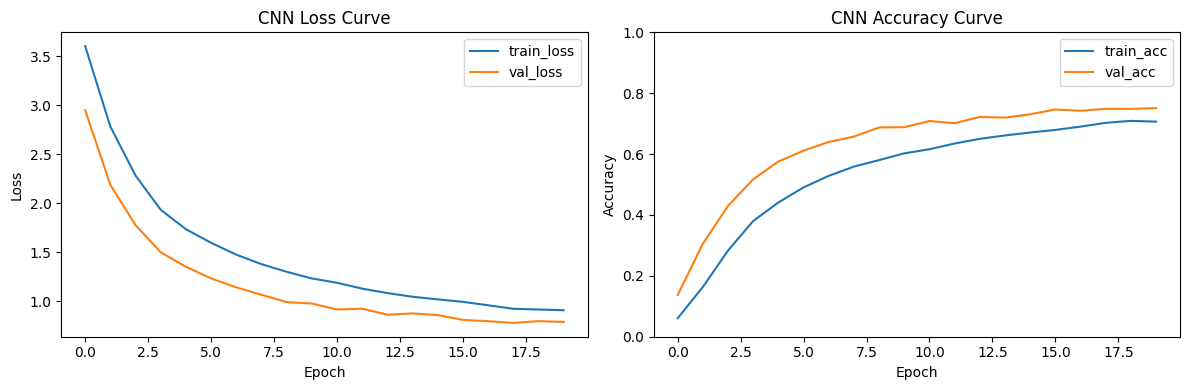

training curves saved to: /content/drive/MyDrive/skeleton_project_outputs/cnn/training_curves_cnn.png


In [12]:
# Plot training curves and save figure
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history["train_loss"], label="train_loss")
plt.plot(history["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Loss Curve")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history["train_acc"], label="train_acc")
plt.plot(history["val_acc"], label="val_acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Accuracy Curve")
plt.ylim(0.0, 1.0)
plt.legend()

plt.tight_layout()
curve_path = os.path.join(SAVE_DIR, "training_curves_cnn.png")
plt.savefig(curve_path, dpi=300, bbox_inches="tight")
plt.show()
print("training curves saved to:", curve_path)


In [13]:
# Cell 11: Load best CNN model and inspect predictions with class names
import pandas as pd
import numpy as np
import torch

ntu60_class_names = [
    "drink water",
    "eat meal",
    "brush teeth",
    "brush hair",
    "drop",
    "pick up",
    "throw",
    "sit down",
    "stand up",
    "clapping",
    "reading",
    "writing",
    "tear up paper",
    "put on jacket",
    "take off jacket",
    "put on a shoe",
    "take off a shoe",
    "put on glasses",
    "take off glasses",
    "put on a hat/cap",
    "take off a hat/cap",
    "cheer up",
    "hand waving",
    "kicking something",
    "reach into pocket",
    "hopping",
    "jump up",
    "phone call",
    "play with phone/tablet",
    "type on a keyboard",
    "point to something",
    "taking a selfie",
    "check time (from watch)",
    "rub two hands",
    "nod head/bow",
    "shake head",
    "wipe face",
    "salute",
    "put palms together",
    "cross hands in front",
    "sneeze/cough",
    "staggering",
    "falling down",
    "headache",
    "chest pain",
    "back pain",
    "neck pain",
    "nausea/vomiting",
    "fan self",
    "punch/slap",
    "kicking",
    "pushing",
    "pat on back",
    "point finger",
    "hugging",
    "giving object",
    "touch pocket",
    "shaking hands",
    "walking towards",
    "walking apart"
]

model.load_state_dict(torch.load(best_model_path, map_location=device))
model.eval()

raw_batch, motion_batch, y_batch = next(iter(val_loader))
raw_batch = raw_batch.to(device)
motion_batch = motion_batch.to(device)
y_batch = y_batch.to(device)

with torch.no_grad():
    logits = model(raw_batch, motion_batch)
    preds = logits.argmax(dim=1)

true_ids = y_batch.cpu().numpy()
pred_ids = preds.cpu().numpy()

num_show = min(20, len(true_ids))

df_pred = pd.DataFrame({
    "sample_id": np.arange(num_show),
    "true_id": true_ids[:num_show],
    "true_name": [ntu60_class_names[i] for i in true_ids[:num_show]],
    "pred_id": pred_ids[:num_show],
    "pred_name": [ntu60_class_names[i] for i in pred_ids[:num_show]],
    "correct": (true_ids[:num_show] == pred_ids[:num_show])
})

df_pred

,sample_id,true_id,true_name,pred_id,pred_name,correct
0,0,0,drink water,0,drink water,True
1,1,1,eat meal,1,eat meal,True
2,2,2,brush teeth,2,brush teeth,True
3,3,3,brush hair,3,brush hair,True
4,4,4,drop,7,sit down,False
5,5,5,pick up,5,pick up,True
6,6,6,throw,6,throw,True
7,7,7,sit down,7,sit down,True
8,8,8,stand up,8,stand up,True
9,9,9,clapping,33,rub two hands,False


In [14]:
# Confusion analysis setup: collect validation predictions once
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

model.load_state_dict(torch.load(best_model_path, map_location=device))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for raw, motion, y in val_loader:
        raw = raw.to(device)
        motion = motion.to(device)
        y = y.to(device)

        logits = model(raw, motion)
        preds = torch.argmax(logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
class_names = globals().get("ntu60_class_names", [str(i) for i in range(cm.shape[0])])
print("num validation samples:", len(all_labels))
print("confusion matrix shape:", cm.shape)


num validation samples: 16487
confusion matrix shape: (60, 60)


raw confusion matrix saved to: /content/drive/MyDrive/skeleton_project_outputs/cnn/confusion_matrix_cnn_raw.png


<Figure size 1600x1400 with 0 Axes>

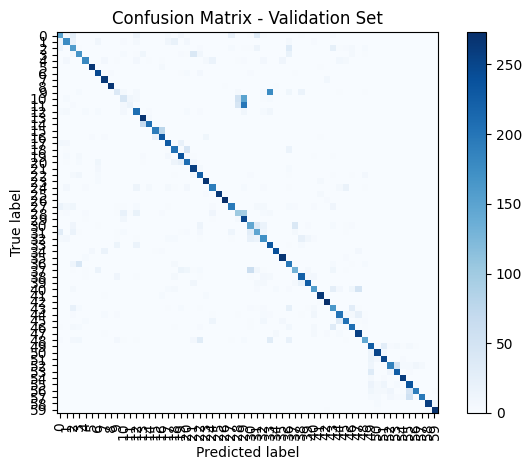

In [15]:
# Save raw confusion matrix
plt.figure(figsize=(16, 14))

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(
    cmap="Blues",
    values_format=None,
    xticks_rotation=90,
    colorbar=True
)

# Hide numbers inside cells to avoid overlap
for text in disp.text_.ravel():
    text.set_visible(False)

plt.title("Confusion Matrix - Validation Set")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()

cm_raw_path = os.path.join(SAVE_DIR, "confusion_matrix_cnn_raw.png")
plt.savefig(cm_raw_path, dpi=300, bbox_inches="tight")
print("raw confusion matrix saved to:", cm_raw_path)
plt.show()


normalized confusion matrix saved to: /content/drive/MyDrive/skeleton_project_outputs/cnn/confusion_matrix_cnn_normalized.png


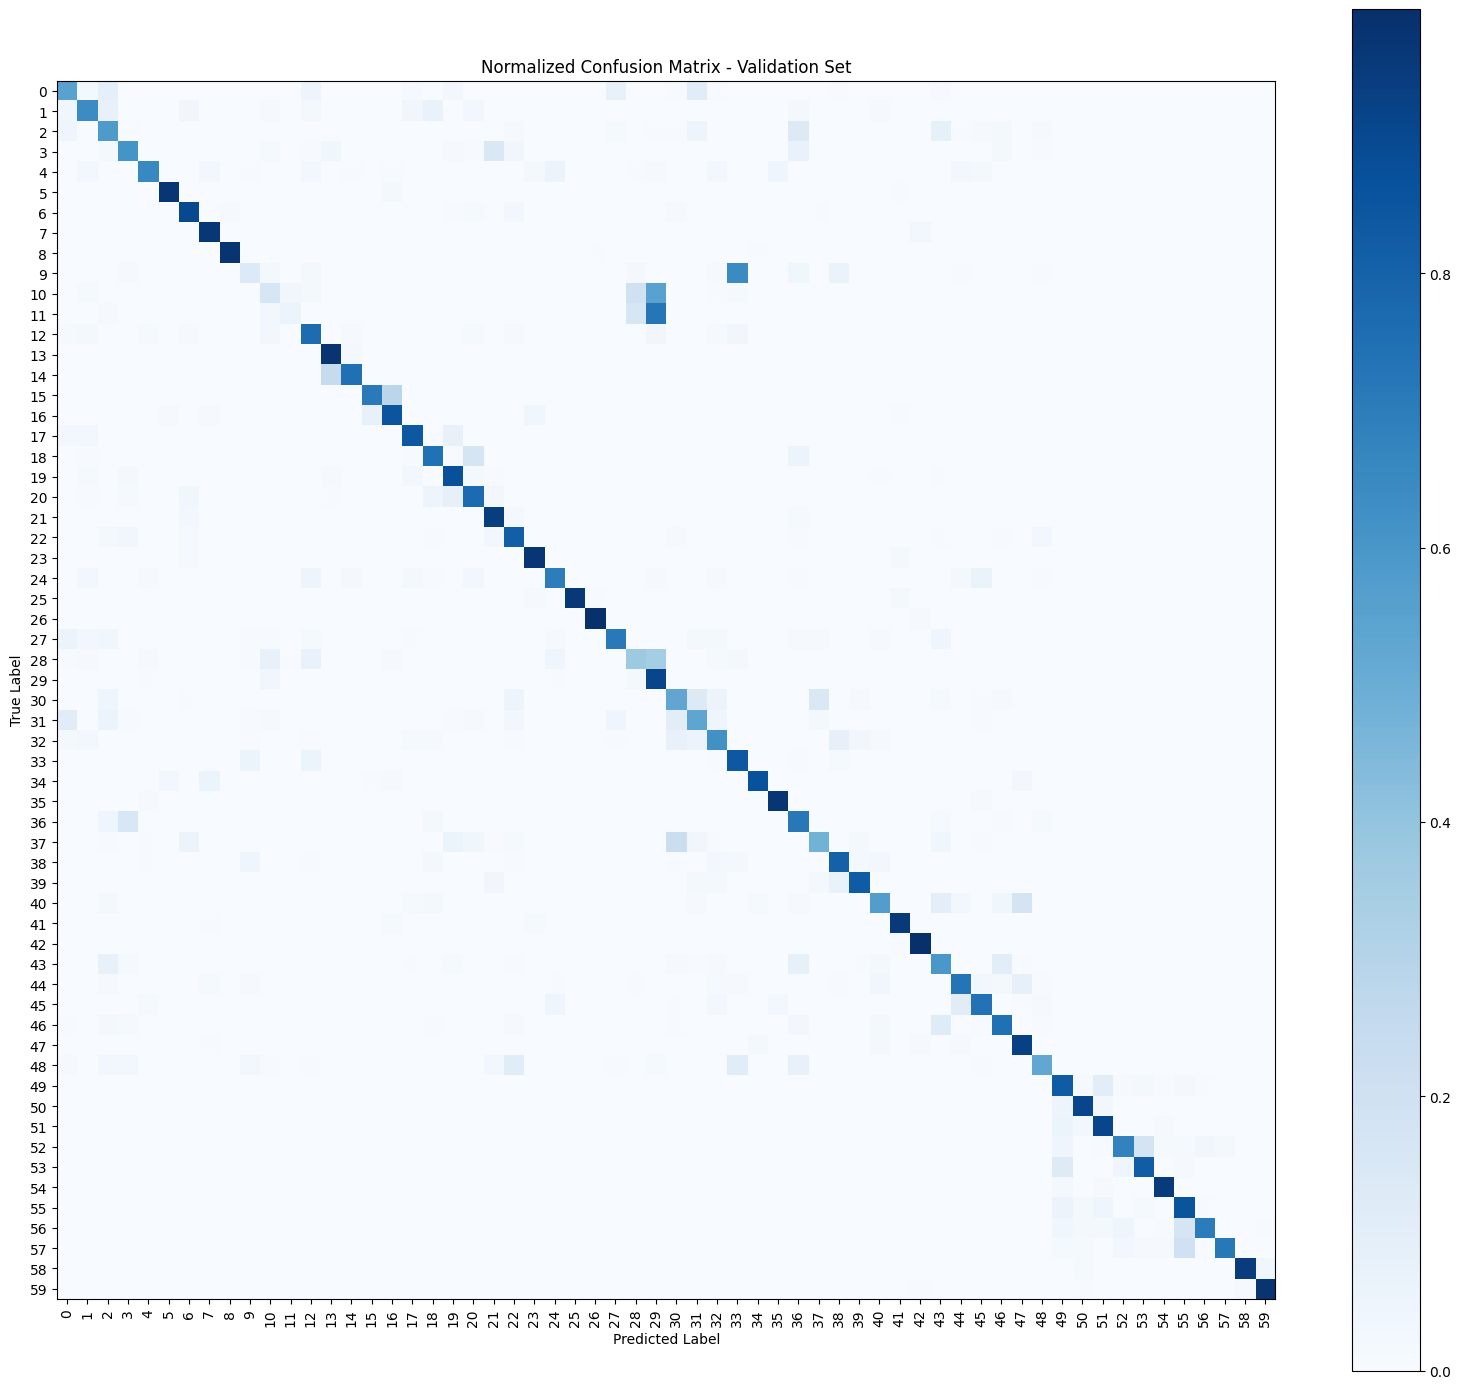

In [16]:
# Save normalized confusion matrix
cm_norm = confusion_matrix(all_labels, all_preds, normalize="true")
fig, ax = plt.subplots(figsize=(16, 14))
disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_norm)
disp_norm.plot(
    ax=ax,
    cmap="Blues",
    values_format=".2f",
    xticks_rotation=90,
    colorbar=True,
)

# Hide dense cell labels; the heatmap is easier to read for 60 classes.
for text in disp_norm.text_.ravel():
    text.set_visible(False)

plt.title("Normalized Confusion Matrix - Validation Set")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
cm_norm_path = os.path.join(SAVE_DIR, "confusion_matrix_cnn_normalized.png")
plt.savefig(cm_norm_path, dpi=300, bbox_inches="tight")
print("normalized confusion matrix saved to:", cm_norm_path)
plt.show()


In [17]:
# Save top confused pairs by raw count
confusions = []

for true_class in range(cm.shape[0]):
    true_total = cm[true_class].sum()
    for pred_class in range(cm.shape[1]):
        count = int(cm[true_class, pred_class])
        if true_class != pred_class and count > 0:
            rate = count / true_total if true_total > 0 else 0.0
            confusions.append({
                "True class": true_class,
                "True name": class_names[true_class] if true_class < len(class_names) else str(true_class),
                "Predicted class": pred_class,
                "Predicted name": class_names[pred_class] if pred_class < len(class_names) else str(pred_class),
                "Count": count,
                "Rate within true class": rate,
            })

confusion_df = pd.DataFrame(confusions)
top_confusions = confusion_df.sort_values(by="Count", ascending=False).head(10)
print(top_confusions)

top_confusions_path = os.path.join(SAVE_DIR, "top_confusions_cnn.csv")
top_confusions.to_csv(top_confusions_path, index=False)
print("top confusions saved to:", top_confusions_path)


     True class               True name  Predicted class  \
148          11                 writing               29   
126           9                clapping               33   
139          10                 reading               29   
296          28  play with phone/tablet               29   
176          15           put on a shoe               16   
175          14         take off jacket               13   
400          37                  salute               30   
601          57           shaking hands               55   
138          10                 reading               28   
561          52             pat on back               53   

             Predicted name  Count  Rate within true class  
148      type on a keyboard    198                0.727941  
126           rub two hands    176                0.644689  
139      type on a keyboard    150                0.549451  
296      type on a keyboard     97                0.352727  
176         take off a shoe     77

In [18]:
# Save top confused pairs by rate within true class
if "confusion_df" not in globals():
    confusions = []
    for true_class in range(cm.shape[0]):
        true_total = cm[true_class].sum()
        for pred_class in range(cm.shape[1]):
            count = int(cm[true_class, pred_class])
            if true_class != pred_class and count > 0:
                rate = count / true_total if true_total > 0 else 0.0
                confusions.append({
                    "True class": true_class,
                    "True name": class_names[true_class] if true_class < len(class_names) else str(true_class),
                    "Predicted class": pred_class,
                    "Predicted name": class_names[pred_class] if pred_class < len(class_names) else str(pred_class),
                    "Count": count,
                    "Rate within true class": rate,
                })
    confusion_df = pd.DataFrame(confusions)

top_confusions_by_rate = confusion_df.sort_values(by="Rate within true class", ascending=False).head(10)
print(top_confusions_by_rate)

top_confusions_rate_path = os.path.join(SAVE_DIR, "top_confusions_cnn_by_rate.csv")
top_confusions_by_rate.to_csv(top_confusions_rate_path, index=False)
print("top confusions by rate saved to:", top_confusions_rate_path)


     True class               True name  Predicted class  \
148          11                 writing               29   
126           9                clapping               33   
139          10                 reading               29   
296          28  play with phone/tablet               29   
176          15           put on a shoe               16   
175          14         take off jacket               13   
400          37                  salute               30   
601          57           shaking hands               55   
138          10                 reading               28   
561          52             pat on back               53   

             Predicted name  Count  Rate within true class  
148      type on a keyboard    198                0.727941  
126           rub two hands    176                0.644689  
139      type on a keyboard    150                0.549451  
296      type on a keyboard     97                0.352727  
176         take off a shoe     77

In [19]:
# Save classification report
report = classification_report(all_labels, all_preds, digits=4)
print(report)

report_path = os.path.join(SAVE_DIR, "classification_report_cnn.txt")
with open(report_path, "w") as f:
    f.write(report)
print("classification report saved to:", report_path)


              precision    recall  f1-score   support

           0     0.6073    0.5474    0.5758       274
           1     0.7333    0.6400    0.6835       275
           2     0.5048    0.5824    0.5408       273
           3     0.6498    0.6117    0.6302       273
           4     0.8696    0.6545    0.7469       275
           5     0.9568    0.9673    0.9620       275
           6     0.7968    0.8982    0.8444       275
           7     0.8680    0.9634    0.9132       273
           8     0.9888    0.9744    0.9815       273
           9     0.4302    0.1355    0.2061       273
          10     0.3909    0.1575    0.2245       273
          11     0.5333    0.0588    0.1060       272
          12     0.6613    0.7638    0.7089       271
          13     0.7528    0.9745    0.8494       275
          14     0.8957    0.7464    0.8142       276
          15     0.8935    0.7070    0.7894       273
          16     0.7082    0.8504    0.7728       274
          17     0.8481    